In [2]:
import numpy as np
import pandas as pd
import locan as lc
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import src.emissions as em

%load_ext autoreload
%autoreload 2

### Load data

In [3]:
exp_data = lc.Files.from_path(files=[r"C:\Users\vie43sq\OneDrive - Universität Würzburg\231002_PCNA_Dominik\data\DOMI-PCNA6-REF-Trimer-dSTORM\Reference-sample-dSTORM\REF_1.5kW-TH1500.txt",
                                     r"C:\Users\vie43sq\OneDrive - Universität Würzburg\231002_PCNA_Dominik\data\DOMI-PCNA6-REF-Trimer-dSTORM\Reference-sample-dSTORM\REF_1.5kW-TH1500_1.txt",
                                     r"C:\Users\vie43sq\OneDrive - Universität Würzburg\231002_PCNA_Dominik\data\DOMI-PCNA6-REF-Trimer-dSTORM\Reference-sample-dSTORM\REF_1.5kW-TH1500_2.txt"])
exp_data.match_file_upstream(pattern='metadata.toml')
locdata = lc.LocData.concat([lc.load_locdata(path=exp_data_x, file_type=lc.FileType.RAPIDSTORM) for exp_data_x in exp_data.df['file_path']])
locdata.meta.MergeFrom(lc.load_metadata_from_toml(r"C:\Users\vie43sq\OneDrive - Universität Würzburg\231002_PCNA_Dominik\data\DOMI-PCNA6-REF-Trimer-dSTORM\metadata.toml")['metadata'])

In [4]:
locdata = lc.transform_counts_to_photons(locdata, loc_properties=['intensity', 'local_background'])

### Select localizations by condition

In [5]:
condition = '120 < intensity and local_background < 22'
locdata = lc.select_by_condition(locdata, condition=condition)
locdata.reduce()

### Clustering

In [6]:
eps = 20
min_samples = 3
noise, cluster = lc.cluster_dbscan(locdata, eps=eps, min_samples=min_samples)
coordinates = np.vstack((locdata.data['position_x'], locdata.data['position_y'])).T
db = DBSCAN(eps=eps, min_samples=min_samples).fit(coordinates)

### Select clusters by condition

In [7]:
condition = '100 < localization_count'
cluster_selected = lc.select_by_condition(cluster, condition=condition)
mask = np.isin(db.labels_, cluster_selected.data.index.values, invert=True)
db.labels_[mask] = -1
locdata.data['cluster_id'] = db.labels_

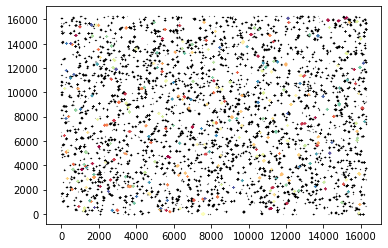

In [8]:
unique_labels = locdata.data['cluster_id'].unique()
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, unique_labels.size)]

groups = locdata.data.groupby('cluster_id')
for (cluster_id, group), color in zip(groups, colors):
    if cluster_id == -1:
        color = [0, 0, 0, 1]
    
    plt.plot(group['position_x'], group['position_y'], 
            "o", ms=0.1, color=color)

### Time series of a cluster

In [9]:
def get_event_time_series(locdata, index, frame_time='5ms'):
    """
    Counts events within a time interval (frame_time).

    Parameters
    ----------
    index : int
        Cluster id (label) of which event_time_series is constructed.
    frame_time : str
        For possible input values, see https://pandas.pydata.org/docs/user_guide/timeseries.html -> Offset aliases.

    Returns
    -------
    event_time_series : pd.Series
        Contains the time points as index and the number of events as values.
    """
    frame_time = pd.Timedelta(frame_time) / np.timedelta64(1, 's')
    time_stamps = np.linspace(0, frame_time*locdata.data['frame'].max(), locdata.data['frame'].max())
    current_data = locdata.data[locdata.data['cluster_id'] == index]
    event_time_series = pd.Series(np.zeros(locdata.data['frame'].max()), index=time_stamps)
    event_time_series.values[current_data['frame']] = current_data['intensity']
    
    return event_time_series

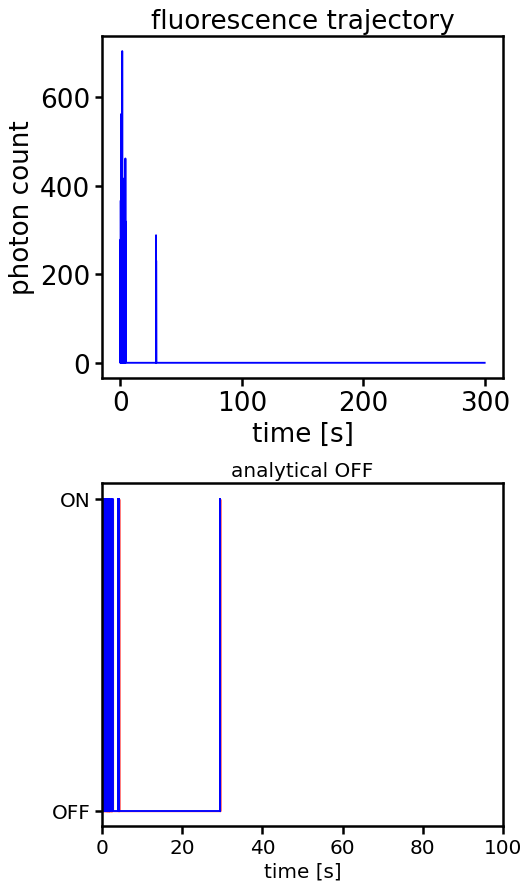

In [10]:
emissions = em.Emissions(frame_time="5ms", seed=100, bandpass=(660, 700))
emissions.event_time_series = get_event_time_series(locdata, 1, '5ms')
on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(emissions.event_time_series)
on_off_times, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods, on_frames, '5ms')
# plot it
axes = fi.universal_figure(nrows=2, fig_height=10, scale=0.9)
emissions.plot_time_series(axes=axes[0])
bl.plot_off_statistics(on_off_times, on_off_values, axes=axes[1], 
                       title="analytical OFF", xlim=[0, 100])
axes[1][0].fill_between(on_off_times, on_off_values, color='red', alpha=0.5)
fig = mi.get_figure(axes)
fig.tight_layout()
        

### analytical ON/OFF of individual clusters

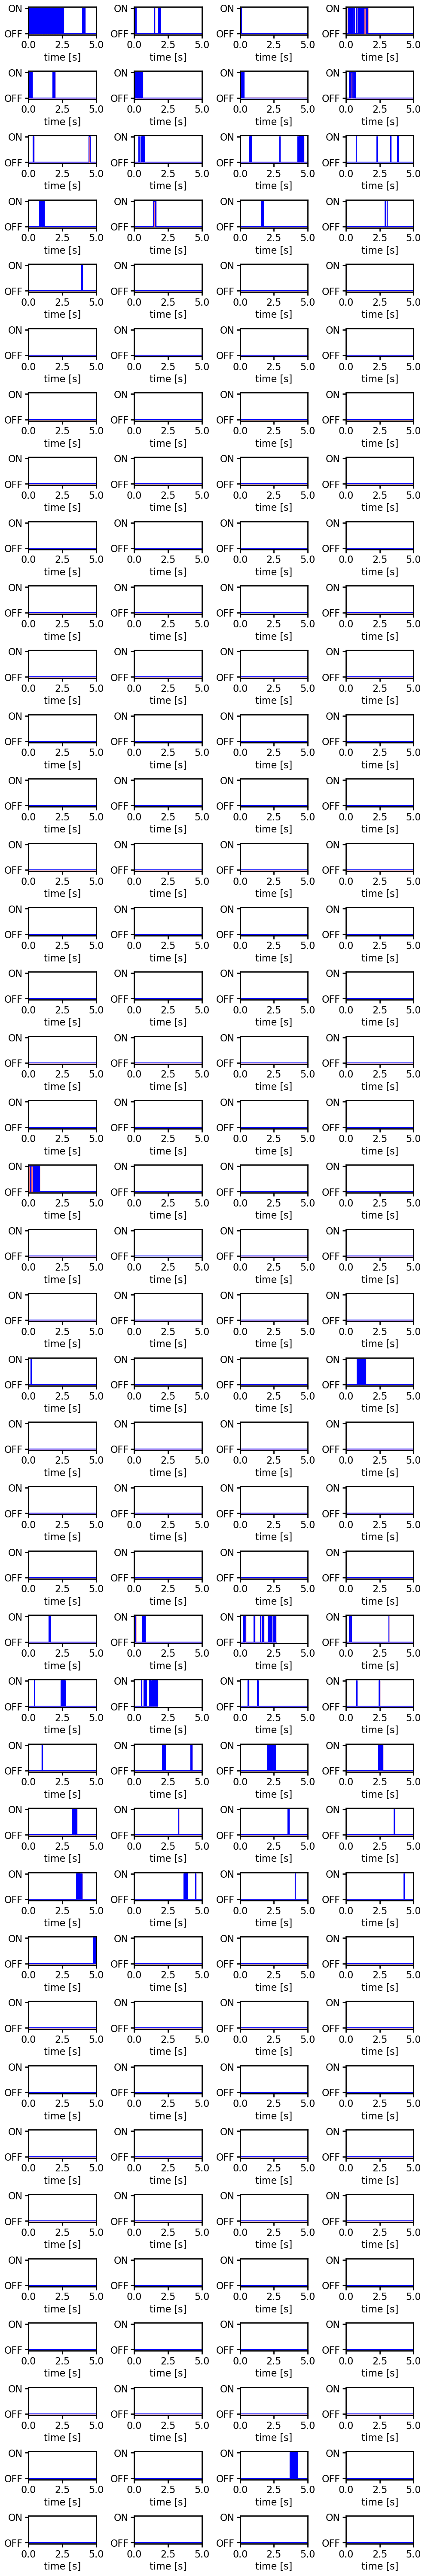

In [11]:
nrows = 40
ncols = 4

axes = fi.universal_figure(nrows=nrows, ncols=ncols, fig_height=nrows*1.5, fig_width=10)
j = 0
h = 0
for i in np.arange(0, nrows*ncols, 1):
    if j > ncols-1:
        h += 1
        j = 0
    index = cluster_selected.data.index.values[i]
    event_time_series = get_event_time_series(locdata, index, '5ms')
    on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
    on_off_times, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods, on_frames, '5ms')
    bl.plot_off_statistics(on_off_times, on_off_values, scale=0.5, axes=axes[h, j], xlim=[0, 5])
    axes[h, j].fill_between(on_off_times, on_off_values, color='red', alpha=0.5)
    j += 1
fig = mi.get_figure(axes)
fig.tight_layout()